In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

df = pd.read_excel('CBDI3_All_Evals_for_NSS_2.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (23947, 220)


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23947 entries, 0 to 23946
Columns: 220 entries, Child ID to Code 10
dtypes: datetime64[ns](14), float64(79), object(127)
memory usage: 40.2+ MB


In [40]:
domains = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive']
score_types = ['Sum of Scaled Scores', 'Developmental Quotient', 'Percentile Rank', 
               '95% Confidence Interval', 'RDI', 'Z-Score', 'T-Score', 'NCE']

domain_cols = []
for d in  domains:
    for s in score_types:
        col_name = d + ' ' + s
        if col_name in df.columns:
            domain_cols.append(col_name)

print(len(domain_cols), 'domain-level score columns identified')

40 domain-level score columns identified


In [41]:
empty_cols = []
for col in df.columns:
    if df[col].isnull().all():
        empty_cols.append(col)

print('Fully empty columns to drop:', empty_cols)
df = df.drop(columns=empty_cols)
print('New shape:', df.shape)

Fully empty columns to drop: ['Code 1', 'Code 2', 'Code 3', 'Code 4', 'Code 5', 'Code 6', 'Code 7', 'Code 8', 'Code 9', 'Code 10']
New shape: (23947, 210)


In [42]:
df['Child ID'] = df['Child ID'].astype(str)

sp_id_count = df['Child ID'].str.startswith('SP').sum()
print('Records with a placeholder SP ID (missing original ID):', sp_id_count)

Records with a placeholder SP ID (missing original ID): 3291


In [43]:
true_dupe_count = df.duplicated().sum()
print('True duplicate rows (exact copies):', true_dupe_count)

df = df.drop_duplicates()
print('Shape after dropping true duplicates:', df.shape)

True duplicate rows (exact copies): 4447
Shape after dropping true duplicates: (19500, 210)


In [44]:
repeat_eval_count = df['Child ID'].duplicated().sum()
print('Rows that share a Child ID with another row (repeat evaluation):', repeat_eval_count)
print('These are expected and should stay in the dataset.')

Rows that share a Child ID with another row (repeat evaluation): 497
These are expected and should stay in the dataset.


In [45]:
repeat_ids = df[df['Child ID'].duplicated(keep=False)]
example_id = repeat_ids['Child ID'].iloc[0]
df[df['Child ID'] == example_id][['Child ID', 'Program Label', 'Date of Birth']]

,Child ID,Program Label,Date of Birth
155,483662,BDI-3 Annual Evaluation,2020-02-29
156,483662,BDI-3 Annual Evaluation,2020-02-29


In [46]:
rdi_cols = []
for col in df.columns:
    if 'rdi' in col.lower():
        rdi_cols.append(col)

print(len(rdi_cols), 'RDI columns found')
print(rdi_cols)

18 RDI columns found
['Adaptive RDI', 'Social-Emotional RDI', 'Communication RDI', 'Motor RDI', 'Cognitive RDI', 'Adaptive-Self Care RDI', 'Adaptive-Personal Responsibility RDI', 'Social Emotional-Adult Interaction RDI', 'Social Emotional-Peer Interaction RDI', 'Social Emotional-Self Concept / Social Role RDI', 'Communication-Receptive Communication RDI', 'Communication-Expressive Communication RDI', 'Motor-Gross Motor RDI', 'Motor-Fine Motor RDI', 'Motor-Perceptual Motor RDI', 'Cognitive-Attention and Memory RDI', 'Cognitive-Reasoning / Academic Skills RDI', 'Cognitive-Perception and Concepts RDI']


In [47]:
def fix_rdi_value(value):
    if isinstance(value, datetime.datetime):
        return str(value.month) + '/90'
    else:
        return value

for col in rdi_cols:
    df[col] = df[col].apply(fix_rdi_value)

def is_datetime_value(value):
    return isinstance(value, datetime.datetime)

leftover_dates = 0
for col in rdi_cols:
    leftover_dates += df[col].apply(is_datetime_value).sum()

print('Leftover date values after the fix:', leftover_dates)    

Leftover date values after the fix: 0


In [48]:
def get_rdi_numerator(value):
    if isinstance(value, str) and '/' in value:
        numerator_text = value.split('/')[0]
        if numerator_text == '<1':
            return 0
        elif numerator_text == '>99':
            return 100
        else:
            return int(numerator_text)
    else:
        return None

for col in rdi_cols:
    new_col_name = col + ' (numeric)'
    df[new_col_name] = df[col].apply(get_rdi_numerator)


In [49]:
df[['Adaptive RDI', 'Adaptive RDI (numeric)']].head(10)

,Adaptive RDI,Adaptive RDI (numeric)
0,39/90,39.0
1,79/90,79.0
2,77/90,77.0
3,99/90,99.0
4,9/90,9.0
5,79/90,79.0
6,71/90,71.0
7,96/90,96.0
8,21/90,21.0
9,91/90,91.0


In [50]:
testing_date_cols = []
for col in df.columns:
    if 'Date of Testing' in col:
        testing_date_cols.append(col)

for col in testing_date_cols:
    problem_rows = df[col] < df['Date of Birth']
    problem_count = problem_rows.sum()
    if problem_count > 0:
        print(col, '-', problem_count, 'rows with a testing date before birth')

In [51]:
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)
missing_pct.head(20)

Adaptive-Personal Responsibility RDI (numeric)         50.358974
Adaptive-Personal Responsibility RDI                   50.358974
Motor-Perceptual Motor RDI (numeric)                   50.333333
Motor-Perceptual Motor RDI                             50.333333
Social Emotional-Peer Interaction RDI (numeric)        50.328205
Social Emotional-Peer Interaction RDI                  50.328205
Motor-Perceptual Motor Z-Score                         50.317949
Motor-Perceptual Motor T-Score                         50.317949
Motor-Perceptual Motor Examiner                        50.317949
Motor-Perceptual Motor Date of Testing                 50.317949
Motor-Perceptual Motor RS                              50.317949
Motor-Perceptual Motor NCE                             50.317949
Motor-Perceptual Motor SS                              50.317949
Motor-Perceptual Motor AE                              50.317949
Motor-Perceptual Motor CSS                             50.317949
Motor-Perceptual Motor CS

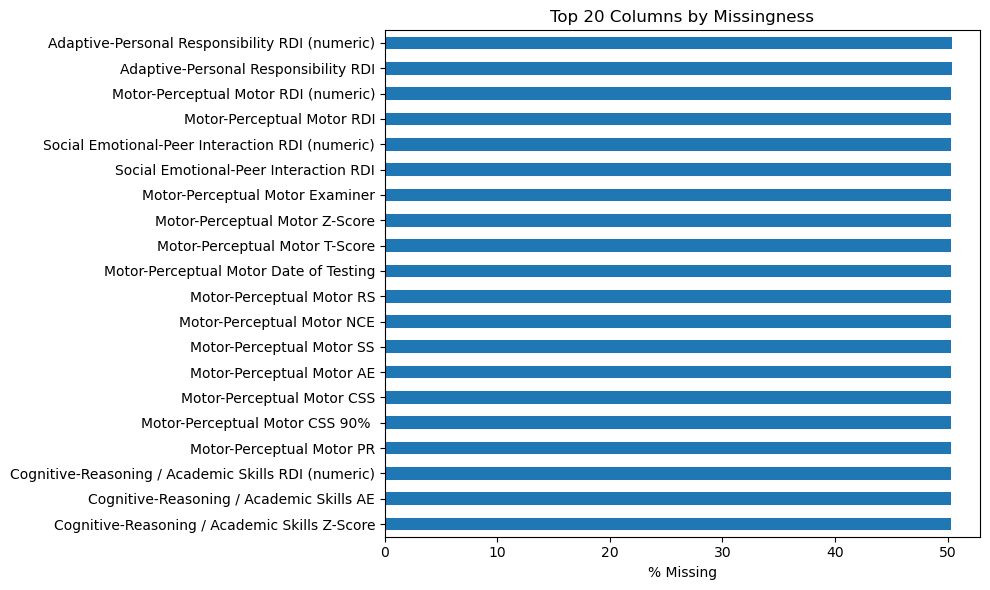

In [52]:
top_20_missing = missing_pct.head(20)

plt.figure(figsize=(10, 6))
top_20_missing.sort_values().plot(kind='barh')
plt.xlabel('% Missing')
plt.title('Top 20 Columns by Missingness')
plt.tight_layout()
plt.show()

In [53]:
dq_cols = []
for d in domains:
    dq_cols.append(d+ ' Developmental Quotient')

print(dq_cols)    

['Adaptive Developmental Quotient', 'Social-Emotional Developmental Quotient', 'Communication Developmental Quotient', 'Motor Developmental Quotient', 'Cognitive Developmental Quotient']


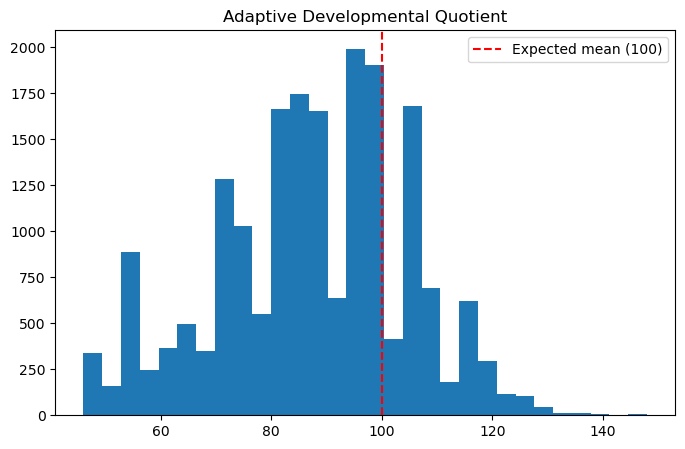

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(df['Adaptive Developmental Quotient'].dropna(), bins=30)
plt.axvline(100, color='red', linestyle='--', label='Expected mean (100)')
plt.title('Adaptive Developmental Quotient')
plt.legend()
plt.show()

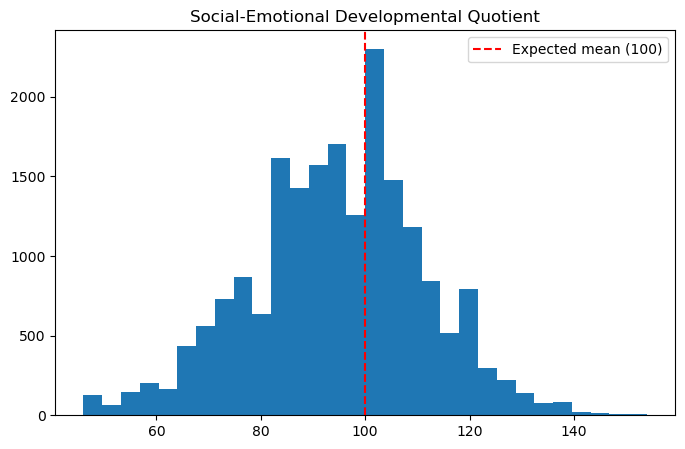

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(df['Social-Emotional Developmental Quotient'].dropna(), bins=30)
plt.axvline(100, color='red', linestyle='--', label='Expected mean (100)')
plt.title('Social-Emotional Developmental Quotient')
plt.legend()
plt.show()

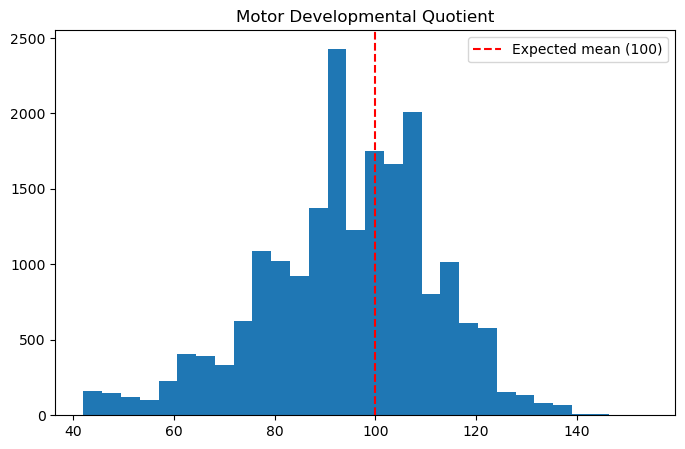

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(df['Motor Developmental Quotient'].dropna(), bins=30)
plt.axvline(100, color='red', linestyle='--', label='Expected mean (100)')
plt.title('Motor Developmental Quotient')
plt.legend()
plt.show()

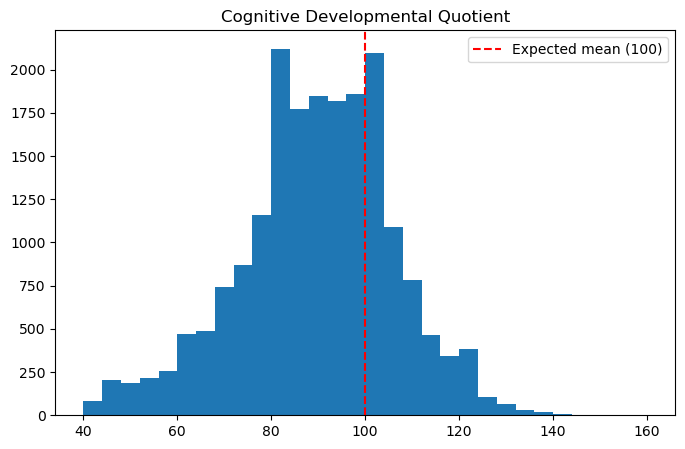

In [57]:
plt.figure(figsize=(8, 5))
plt.hist(df['Cognitive Developmental Quotient'].dropna(), bins=30)
plt.axvline(100, color='red', linestyle='--', label='Expected mean (100)')
plt.title('Cognitive Developmental Quotient')
plt.legend()
plt.show()

In [58]:
df[dq_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Adaptive Developmental Quotient,19493.0,87.435079,17.438731,46.0,76.0,88.0,100.0,148.0
Social-Emotional Developmental Quotient,19483.0,94.470051,16.695712,46.0,84.0,96.0,106.0,154.0
Communication Developmental Quotient,19469.0,79.604499,20.168400,46.0,64.0,79.0,94.0,154.0
Motor Developmental Quotient,19471.0,94.511222,17.288802,42.0,85.0,96.0,106.0,154.0
Cognitive Developmental Quotient,19481.0,89.061804,16.498114,40.0,80.0,90.0,100.0,160.0


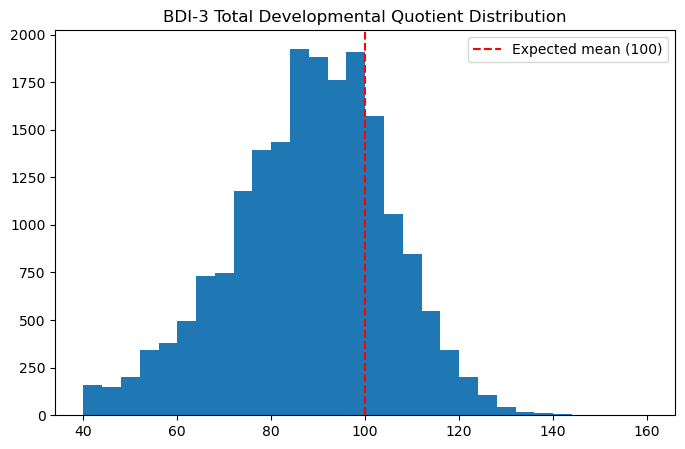

count    19443.000000
mean        87.687600
std         16.866901
min         40.000000
25%         77.000000
50%         89.000000
75%         99.000000
max        160.000000
Name: BDI-3 Total Developmental Quotient, dtype: float64


In [59]:
plt.figure(figsize=(8, 5))
plt.hist(df['BDI-3 Total Developmental Quotient'].dropna(), bins=30)
plt.axvline(100, color='red', linestyle='--', label='Expected mean (100)')
plt.title('BDI-3 Total Developmental Quotient Distribution')
plt.legend()
plt.show()

print(df['BDI-3 Total Developmental Quotient'].describe())

In [60]:
gender_summary = df.groupby('Gender')[dq_cols].mean().round(1)
gender_summary

,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient
Gender,,,,,
F,89.2,96.3,82.8,95.1,90.6
M,86.3,93.4,77.5,94.1,88.0
U,89.7,92.8,84.5,99.0,94.5


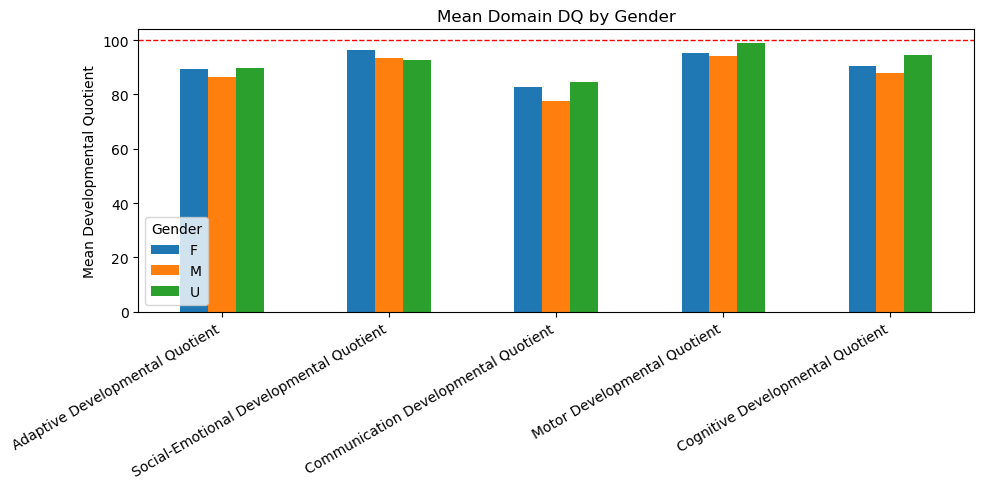

In [61]:
gender_summary.T.plot(kind='bar', figsize=(10, 5))
plt.axhline(100, color='red', linestyle='--', linewidth=1)
plt.ylabel('Mean Developmental Quotient')
plt.title('Mean Domain DQ by Gender')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [62]:
region_summary = df.groupby('Location - Sub Level 1')[dq_cols].mean().round(1)
region_summary

,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient
Location - Sub Level 1,,,,,
East Tennessee,86.5,91.9,81.7,94.4,89.5
First Tennessee,85.5,91.5,81.4,94.3,90.2
Greater Nashville,88.9,97.6,79.7,94.9,90.4
Memphis Delta,86.3,96.3,77.2,94.4,88.4
Northwest,90.6,99.8,81.5,97.6,91.2
South Central,86.6,90.3,76.6,91.7,85.1
Southeast Tennessee,87.4,95.4,79.5,94.1,90.8
Southwest,90.4,98.7,81.2,98.3,90.8
Upper Cumberland,87.3,93.0,80.2,94.9,88.0


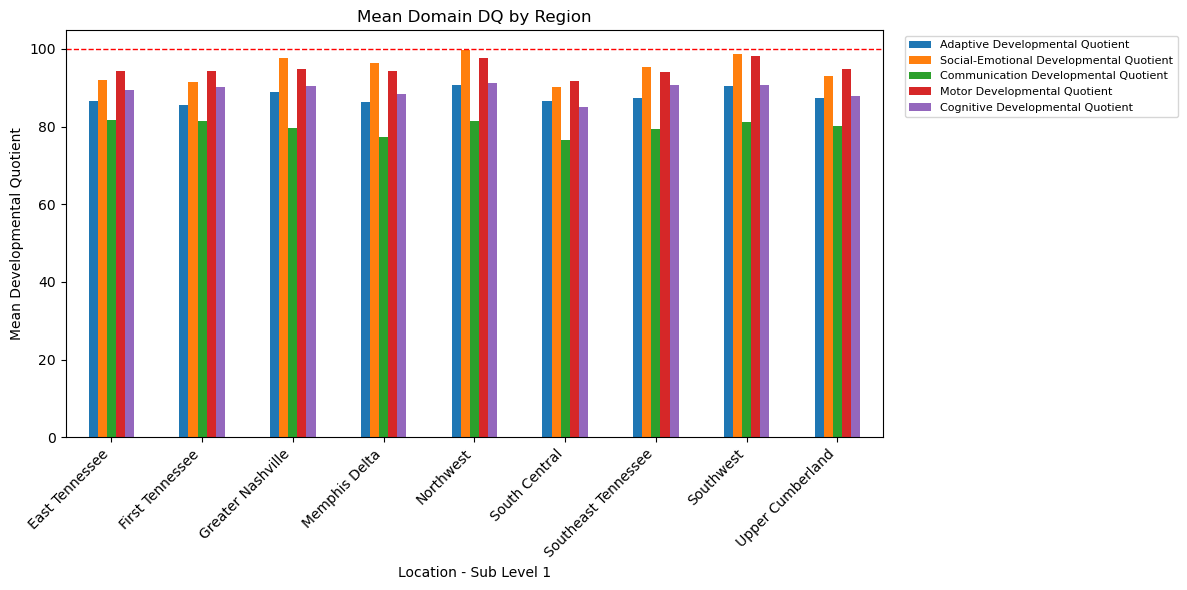

In [63]:
region_summary.plot(kind='bar', figsize=(12, 6))
plt.axhline(100, color='red', linestyle='--', linewidth=1)
plt.ylabel('Mean Developmental Quotient')
plt.title('Mean Domain DQ by Region')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [64]:
df['Location - Sub Level 1'].value_counts(dropna=False)

Location - Sub Level 1
Greater Nashville      3436
East Tennessee         3340
Memphis Delta          2717
South Central          2560
Upper Cumberland       2021
First Tennessee        1701
Southeast Tennessee    1583
Southwest              1100
Northwest               955
NaN                      87
Name: count, dtype: int64

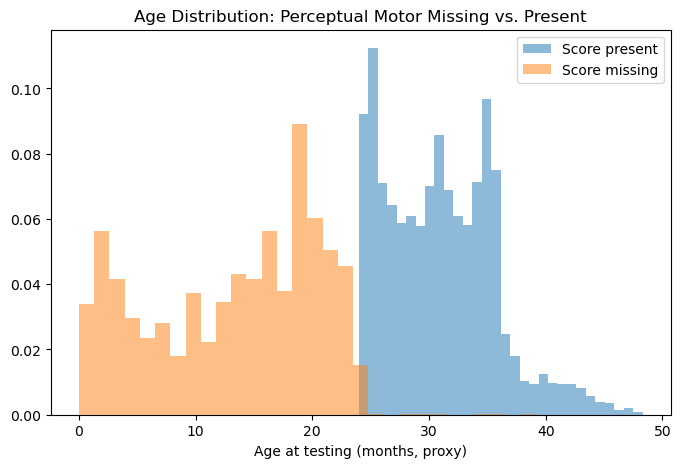

In [65]:
pm_date_col = 'Motor-Perceptual Motor Date of Testing'
df['age_months_at_pm_test'] = (df[pm_date_col] - df['Date of Birth']).dt.days / 30.44

df['pm_missing'] = df['Motor-Perceptual Motor SS'].isnull()

age_proxy_col = 'Adaptive-Self Care Date of Testing'
df['age_months_proxy'] = (df[age_proxy_col] - df['Date of Birth']).dt.days / 30.44

age_missing = df[df['pm_missing'] == True]['age_months_proxy']
age_present = df[df['pm_missing'] == False]['age_months_proxy']

plt.figure(figsize=(8, 5))
plt.hist(age_present.dropna(), bins=30, alpha=0.5, label='Score present', density=True)
plt.hist(age_missing.dropna(), bins=30, alpha=0.5, label='Score missing', density=True)
plt.title('Age Distribution: Perceptual Motor Missing vs. Present')
plt.xlabel('Age at testing (months, proxy)')
plt.legend()
plt.show()

In [66]:
missing_by_program = df.groupby('Program Label')['pm_missing'].mean() * 100
missing_by_program.round(1)

Program Label
BDI-3 Annual Evaluation               23.4
BDI-3 Eligibility Evaluation          66.1
BDI-3 Milestone or Exit Evaluation     1.0
Name: pm_missing, dtype: float64

In [67]:
program_labels = df['Program Label'].unique()

results = {}
for label in program_labels:
    subset = df[df['Program Label'] == label]
    missing_rates = []
    for col in dq_cols:
        pct_missing = subset[col].isnull().mean() * 100
        missing_rates.append(round(pct_missing, 1))
    results[label] = missing_rates

missing_by_program_table = pd.DataFrame(results, index=dq_cols).T
missing_by_program_table

,Adaptive Developmental Quotient,Social-Emotional Developmental Quotient,Communication Developmental Quotient,Motor Developmental Quotient,Cognitive Developmental Quotient
BDI-3 Eligibility Evaluation,0.0,0.1,0.2,0.1,0.1
BDI-3 Annual Evaluation,0.0,0.1,0.1,0.2,0.1
BDI-3 Milestone or Exit Evaluation,0.0,0.0,0.0,0.0,0.0


In [68]:
pr_cols = []
for col in df.columns:
    if col.endswith('Percentile Rank') or col.endswith(' PR'):
        pr_cols.append(col)

print(len(pr_cols), 'Percentile Rank columns found')

def clean_capped_number(value):
    if value == '<1':
        return 0
    elif value == '>99':
        return 100
    else:
        return value

for col in pr_cols:
    df[col] = df[col].apply(clean_capped_number)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('All PR columns converted to numbers.')

19 Percentile Rank columns found
All PR columns converted to numbers.


In [69]:
domains = ['Adaptive', 'Social-Emotional', 'Communication', 'Motor', 'Cognitive']

dq_cols = []
for d in domains:
    dq_cols.append(d + ' Developmental Quotient')

domain_pr_cols = []
for d in domains:
    domain_pr_cols.append(d + ' Percentile Rank')

subdomain_pr_cols = [
    'Adaptive-Self Care PR',
    'Adaptive-Personal Responsibility PR',
    'Social Emotional-Adult Interaction PR',
    'Social Emotional-Peer Interaction PR',
    'Social Emotional-Self Concept / Social Role PR',
    'Communication-Receptive Communication PR',
    'Communication-Expressive Communication PR',
    'Motor-Gross Motor PR',
    'Motor-Fine Motor PR',
    'Motor-Perceptual Motor PR',
    'Cognitive-Attention and Memory PR',
    'Cognitive-Reasoning / Academic Skills PR',
    'Cognitive-Perception and Concepts PR'
]

1. In which domains (and sub-domains) are children performing highest and lowest?

In [70]:
domain_avg_pr = df[domain_pr_cols].mean()
domain_avg_pr = domain_avg_pr.sort_values()
print(domain_avg_pr)

Communication Percentile Rank       23.943019
Adaptive Percentile Rank            30.438956
Cognitive Percentile Rank           32.232907
Social-Emotional Percentile Rank    40.980483
Motor Percentile Rank               42.442523
dtype: float64


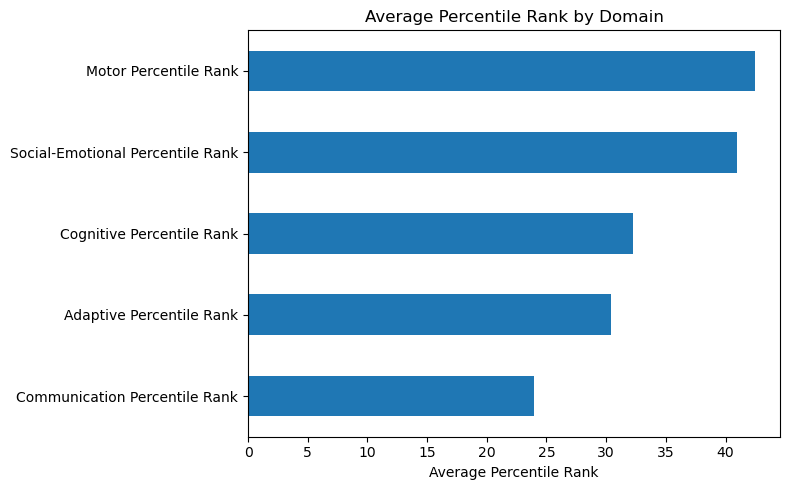

In [71]:
plt.figure(figsize=(8, 5))
domain_avg_pr.plot(kind='barh')
plt.xlabel('Average Percentile Rank')
plt.title('Average Percentile Rank by Domain')
plt.tight_layout()
plt.show()

In [72]:
subdomain_avg_pr = df[subdomain_pr_cols].mean()
subdomain_avg_pr = subdomain_avg_pr.sort_values()
print(subdomain_avg_pr)

Communication-Expressive Communication PR         23.241629
Communication-Receptive Communication PR          24.957711
Adaptive-Self Care PR                             27.917462
Cognitive-Perception and Concepts PR              31.091110
Social Emotional-Peer Interaction PR              32.030225
Social Emotional-Self Concept / Social Role PR    33.257980
Cognitive-Reasoning / Academic Skills PR          33.882905
Adaptive-Personal Responsibility PR               34.511961
Cognitive-Attention and Memory PR                 34.890012
Motor-Gross Motor PR                              37.803572
Motor-Perceptual Motor PR                         40.943126
Motor-Fine Motor PR                               48.693086
Social Emotional-Adult Interaction PR             55.212992
dtype: float64


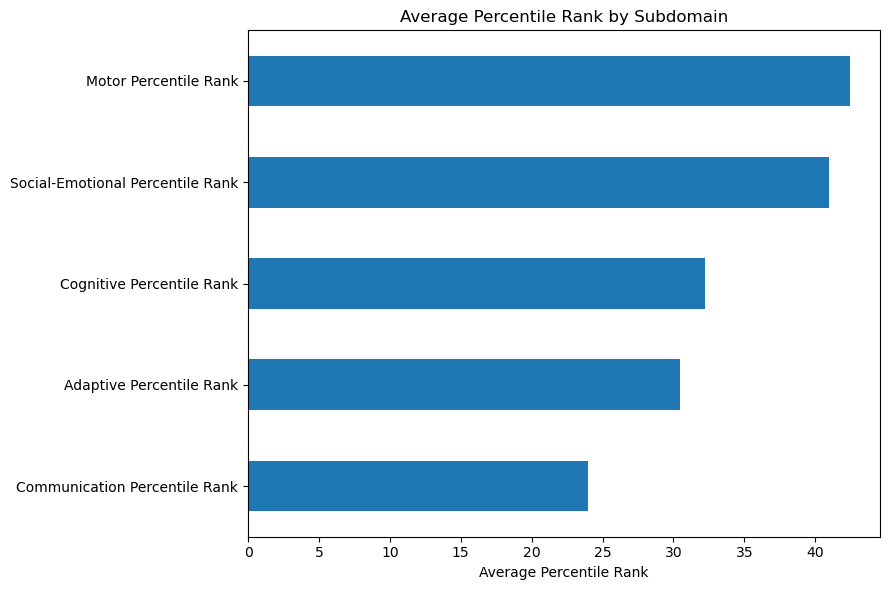

In [73]:
plt.figure(figsize=(9, 6))
domain_avg_pr.plot(kind='barh')
plt.xlabel('Average Percentile Rank')
plt.title('Average Percentile Rank by Subdomain')
plt.tight_layout()
plt.show()

2. What is the pattern of children's scores?

 Do individual children tend to perform similarly across all domains or are there differences from domain to domain?
 
 Are these patterns similar for all children?

In [75]:
df['domain_pr_max'] = df[domain_pr_cols].max(axis=1)
df['domain_pr_min'] = df[domain_pr_cols].min(axis=1)
df['domain_pr_spread'] = df['domain_pr_max'] - df['domain_pr_min']

print(df['domain_pr_spread'].describe())

count    19470.000000
mean        45.513215
std         23.467998
min          0.000000
25%         28.000000
50%         46.000000
75%         63.750000
max         99.600000
Name: domain_pr_spread, dtype: float64


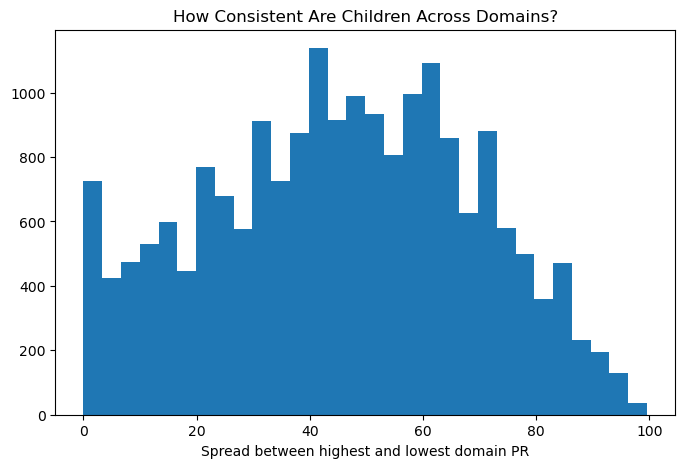

In [77]:
plt.figure(figsize=(8, 5))
plt.hist(df['domain_pr_spread'].dropna(), bins=30)
plt.xlabel('Spread between highest and lowest domain PR')
plt.title('How Consistent Are Children Across Domains?')
plt.show()

3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain?

For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility.

A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language 

In [78]:
df['communication_gap'] = df['Communication-Expressive Communication PR'] - df['Communication-Receptive Communication PR']

print(df['communication_gap'].describe())

count    19469.000000
mean        -1.699265
std         22.928667
min        -99.000000
25%        -11.000000
50%          0.000000
75%          8.000000
max         95.000000
Name: communication_gap, dtype: float64


C:\Users\gaine\AppData\Local\Temp\ipykernel_27208\2190411722.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['communication_gap'] = df['Communication-Expressive Communication PR'] - df['Communication-Receptive Communication PR']


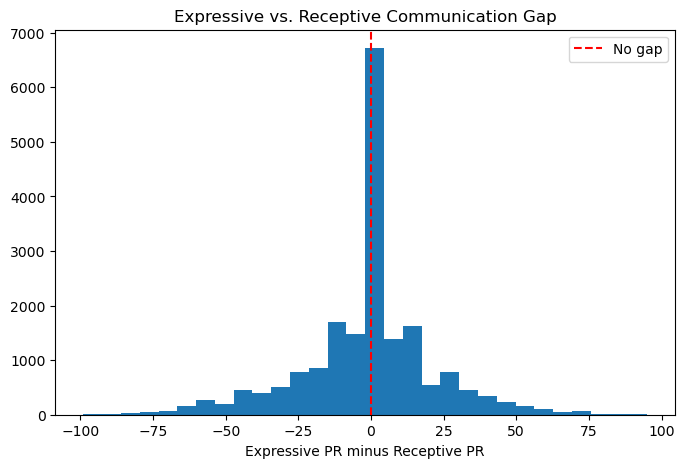

In [79]:
plt.figure(figsize=(8, 5))
plt.hist(df['communication_gap'].dropna(), bins=30)
plt.axvline(0, color='red', linestyle='--', label='No gap')
plt.xlabel('Expressive PR minus Receptive PR')
plt.title('Expressive vs. Receptive Communication Gap')
plt.legend()
plt.show()

4. Does the child's age seem to impact their scoring?

In [81]:
age_col = 'Adaptive-Self Care Date of Testing'
df['age_months'] = (df[age_col] - df['Date of Birth']).dt.days / 30.44

correlation_table = df[['age_months', 'BDI-3 Total Percentile Rank']].corr()
print(correlation_table)

                             age_months  BDI-3 Total Percentile Rank
age_months                     1.000000                    -0.252582
BDI-3 Total Percentile Rank   -0.252582                     1.000000


C:\Users\gaine\AppData\Local\Temp\ipykernel_27208\787447782.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_months'] = (df[age_col] - df['Date of Birth']).dt.days / 30.44


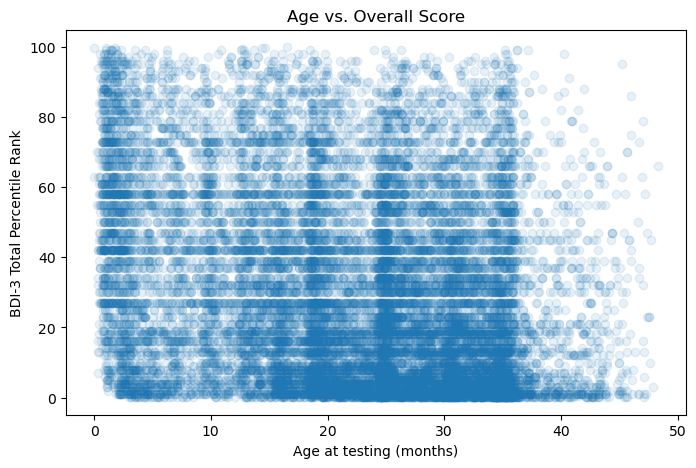

In [82]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age_months'], df['BDI-3 Total Percentile Rank'], alpha=0.1)
plt.xlabel('Age at testing (months)')
plt.ylabel('BDI-3 Total Percentile Rank')
plt.title('Age vs. Overall Score')
plt.show()

5. Eligibility is currently based on domains.
A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores.

A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay.

If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

In [85]:
def is_currently_eligible(row):
    delay_40_count = 0
    delay_25_count = 0
    for col in dq_cols:
        dq = row[col]
        if pd.isna(dq):
            continue
        if dq <= 70:
            delay_40_count += 1
        elif dq <= 78:
            delay_25_count += 1
    if delay_40_count >= 1:
        return True
    if delay_25_count >= 2:
        return True
    return False

df['currently_eligible'] = df.apply(is_currently_eligible, axis=1)
df['alternate_eligible'] = df['BDI-3 Total Developmental Quotient'] <= 70

print('Currently eligible (existing rule):', df['currently_eligible'].sum())
print('Would qualify under Total DQ rule:', df['alternate_eligible'].sum())    
    

Currently eligible (existing rule): 9427
Would qualify under Total DQ rule: 3002


In [87]:
newly_qualified = df[(df['alternate_eligible'] == True) & (df['currently_eligible'] == False)]

print("Number of children who would newly qualify:", len(newly_qualified))

Number of children who would newly qualify: 0


6. Is there any difference in scoring noted based on evaluation type?

In [88]:
eval_type_summary = df.groupby('Program Label')[dq_cols].mean().round(1)
print(eval_type_summary)

                                    Adaptive Developmental Quotient  \
Program Label                                                         
BDI-3 Annual Evaluation                                        84.4   
BDI-3 Eligibility Evaluation                                   89.2   
BDI-3 Milestone or Exit Evaluation                             85.6   

                                    Social-Emotional Developmental Quotient  \
Program Label                                                                 
BDI-3 Annual Evaluation                                                92.8   
BDI-3 Eligibility Evaluation                                           95.4   
BDI-3 Milestone or Exit Evaluation                                     93.1   

                                    Communication Developmental Quotient  \
Program Label                                                              
BDI-3 Annual Evaluation                                             76.9   
BDI-3 Eligibility Ev

In [90]:
print(df['Program Label'].value_counts())

Program Label
BDI-3 Eligibility Evaluation          12392
BDI-3 Annual Evaluation                6905
BDI-3 Milestone or Exit Evaluation      203
Name: count, dtype: int64


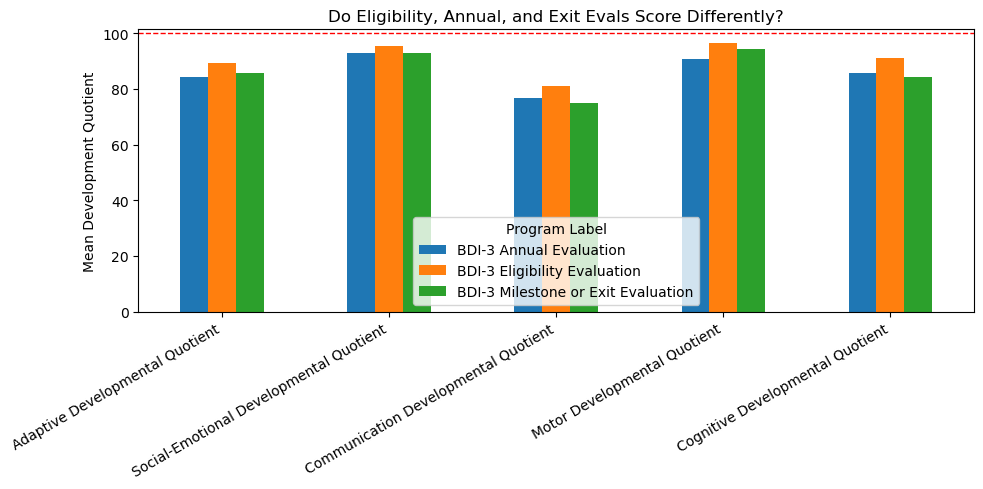

In [92]:
eval_type_summary.T.plot(kind='bar', figsize=(10, 5))
plt.axhline(100, color='red', linestyle='--', linewidth=1)
plt.ylabel('Mean Development Quotient')
plt.title('Do Eligibility, Annual, and Exit Evals Score Differently?')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
* East TN, First TN and Southeast
* Greater Nashville, Upper Cumberland, and South Central
* Northwest, Southwest, and Memphis Delta
